In [1]:
#config
import glob
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_GLOB = "/mnt/project/**/*street.csv"


TEST_MONTHS = 12

VALIDATION_MODE = "most_recent"   
RANDOM_SEED = 42

In [ ]:
#monthly panel
#takes about 6 minutes to run on my laptop
USECOLS = ["Month", "Falls within", "Crime type"]
DATA_GLOB = "C:/Users/20244270/OneDrive - TU Eindhoven/Desktop/CBL-midterm/**/*street.csv"

files = glob.glob(DATA_GLOB, recursive=True)
print(f"Found {len(files)} street files")

frames = []
for f in files:
    # Some monthly files can be empty / malformed; skip those rather than abort.
    try:
        df = pd.read_csv(f, usecols=USECOLS)
    except (ValueError, pd.errors.EmptyDataError):
        continue
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
raw = raw.dropna(subset=USECOLS)
print(f"{len(raw):,} crime records loaded")

# Count: one row per (force, crime_type, month).
panel = (
    raw.groupby(["Falls within", "Crime type", "Month"])
       .size()
       .reset_index(name="n_crimes")
       .rename(columns={"Falls within": "force", "Crime type": "crime_type"})
)
panel["month"] = pd.to_datetime(panel["Month"], format="%Y-%m")
panel = panel.drop(columns="Month")
print(f"Panel shape: {panel.shape}")
panel.head()

Found 6809 street files
78,847,765 crime records loaded
Panel shape: (95187, 4)


,force,crime_type,n_crimes,month
0,Avon and Somerset Constabulary,Anti-social behaviour,6012,2013-05-01
1,Avon and Somerset Constabulary,Anti-social behaviour,6205,2013-06-01
2,Avon and Somerset Constabulary,Anti-social behaviour,7696,2013-07-01
3,Avon and Somerset Constabulary,Anti-social behaviour,7075,2013-08-01
4,Avon and Somerset Constabulary,Anti-social behaviour,5688,2013-09-01


In [3]:
# Drop forces excluded from analysis
FORCES_DROP = {
    "British Transport Police",
    "Police Service of Northern Ireland",
    "Greater Manchester Police",
}
before = panel["force"].nunique()
panel = panel[~panel["force"].isin(FORCES_DROP)].copy()
after = panel["force"].nunique()
print(f"Dropped {before - after} forces: {', '.join(sorted(FORCES_DROP))}")
print(f"Remaining: {after} forces")

Dropped 3 forces: British Transport Police, Greater Manchester Police, Police Service of Northern Ireland
Remaining: 42 forces


In [4]:
#Make grid dense
def densify(panel):
    out = []
    for (force, ctype), g in panel.groupby(["force", "crime_type"]):
        months = pd.date_range(g["month"].min(), g["month"].max(), freq="MS")
        idx = pd.DataFrame({"month": months})
        idx["force"] = force
        idx["crime_type"] = ctype
        out.append(idx)
    grid = pd.concat(out, ignore_index=True)
    dense = grid.merge(panel, on=["force", "crime_type", "month"], how="left")
    dense["n_crimes"] = dense["n_crimes"].fillna(0).astype(int)
    return dense.sort_values(["force", "crime_type", "month"]).reset_index(drop=True)

dense = densify(panel)
print(f"Dense panel: {dense.shape}")
dense.head()

Dense panel: (90440, 4)


,month,force,crime_type,n_crimes
0,2013-05-01,Avon and Somerset Constabulary,Anti-social behaviour,6012
1,2013-06-01,Avon and Somerset Constabulary,Anti-social behaviour,6205
2,2013-07-01,Avon and Somerset Constabulary,Anti-social behaviour,7696
3,2013-08-01,Avon and Somerset Constabulary,Anti-social behaviour,7075
4,2013-09-01,Avon and Somerset Constabulary,Anti-social behaviour,5688


In [5]:
# Impute gaps using seasonal carry forward imputation


GLOBAL_END = dense["month"].max()

# Forces to extend to GLOBAL_END before imputation
EXTEND_TO_END = {
    "Gwent Police",
    "Northumbria Police",
    "Gloucestershire Constabulary",
}

# Known gap months per force
GAP_MONTHS = {
    "Devon & Cornwall Police": list(pd.date_range("2022-11-01", "2023-02-01", freq="MS")),
    "Gloucestershire Constabulary": (
        list(pd.date_range("2020-03-01", "2020-03-01", freq="MS")) +
        list(pd.date_range("2026-02-01", "2026-02-01", freq="MS"))
    ),
    "Gwent Police":       list(pd.date_range("2025-09-01", "2026-02-01", freq="MS")),
    "Northumbria Police": list(pd.date_range("2025-09-01", "2026-02-01", freq="MS")),
}


def impute_seasonal(s, gap_months):
    """Seasonal carry-forward: imputed(m) = value(m-12) + [value(m-12) - value(m-13)]."""
    s = s.copy()
    for m in sorted(gap_months):
        m12 = m - pd.DateOffset(months=12)
        m13 = m - pd.DateOffset(months=13)
        v12 = s.get(m12, np.nan)
        v13 = s.get(m13, np.nan)
        if pd.notna(v12) and pd.notna(v13):
            s[m] = max(0.0, v12 + (v12 - v13))
        elif pd.notna(v12):
            s[m] = float(v12)
        else:
            s[m] = 0.0
    return s


# Step 1: extend series that ended before the global end month
ext_rows = []
for force in EXTEND_TO_END:
    force_data = dense[dense["force"] == force]
    if force_data.empty:
        continue
    last_month = force_data["month"].max()
    if last_month >= GLOBAL_END:
        continue
    new_months = pd.date_range(
        last_month + pd.DateOffset(months=1), GLOBAL_END, freq="MS"
    )
    for ctype in force_data["crime_type"].unique():
        for m in new_months:
            ext_rows.append({"force": force, "crime_type": ctype, "month": m, "n_crimes": 0})

if ext_rows:
    dense = pd.concat([dense, pd.DataFrame(ext_rows)], ignore_index=True)
    dense = dense.sort_values(["force", "crime_type", "month"]).reset_index(drop=True)
    print(f"Extended {len(ext_rows)} rows to reach {GLOBAL_END.strftime('%Y-%m')}")

# Step 2: apply seasonal carry-forward to each affected (force, crime_type) series
imputed_cells = 0
for force, gap_ms in GAP_MONTHS.items():
    gap_set = {pd.Timestamp(m) for m in gap_ms}
    mask_force = dense["force"] == force
    for ctype in dense.loc[mask_force, "crime_type"].unique():
        mask = mask_force & (dense["crime_type"] == ctype)
        s = dense.loc[mask].set_index("month")["n_crimes"].astype(float)
        s_imp = impute_seasonal(s, gap_set)
        for m in gap_set:
            if m in s_imp.index:
                row_mask = mask & (dense["month"] == m)
                dense.loc[row_mask, "n_crimes"] = int(round(s_imp[m]))
                imputed_cells += int(row_mask.sum())

print(f"Imputed {imputed_cells} (force x crime_type x month) cells across {len(GAP_MONTHS)} forces")
print(f"Dense panel after imputation: {dense.shape}")

Extended 112 rows to reach 2026-02
Imputed 252 (force x crime_type x month) cells across 4 forces
Dense panel after imputation: (90552, 4)


In [6]:
#feature engineering
LAGS = [1, 2, 3, 6, 12]
ROLL_WINDOWS = [3, 12]

def add_features(df):
    df = df.sort_values(["force", "crime_type", "month"]).copy()
    grp = df.groupby(["force", "crime_type"])["n_crimes"]

    for lag in LAGS:
        df[f"lag_{lag}"] = grp.shift(lag)

    # Rolling stats per series, so the window never bleeds across
    # (force, crime_type) boundaries.
    for w in ROLL_WINDOWS:
        df[f"rmean_{w}"] = grp.transform(lambda s: s.shift(1).rolling(w).mean())
        df[f"rstd_{w}"]  = grp.transform(lambda s: s.shift(1).rolling(w).std())

    df["month_of_year"] = df["month"].dt.month
    df["quarter"] = df["month"].dt.quarter
    return df

feat = add_features(dense)
feat = feat.dropna(subset=["lag_1"]).reset_index(drop=True)

# force and crime_type as pandas 'category' -> LightGBM uses native categorical
# splits (better than one-hot for high-cardinality, per the LightGBM docs).
feat["force"] = feat["force"].astype("category")
feat["crime_type"] = feat["crime_type"].astype("category")

FEATURES = (
    ["force", "crime_type", "month_of_year", "quarter"]
    + [f"lag_{l}" for l in LAGS]
    + [f"rmean_{w}" for w in ROLL_WINDOWS]
    + [f"rstd_{w}" for w in ROLL_WINDOWS]
)
CATEGORICAL = ["force", "crime_type"]
TARGET = "n_crimes"
print(f"{len(feat):,} training-eligible rows, {len(FEATURES)} features")

89,964 training-eligible rows, 13 features


In [ ]:
# Time-aware train/test split with a hard cutoff: (train before sarima for later comparison)
# the model trains ONLY on months strictly before CUTOFF.
months_sorted = np.sort(feat["month"].unique())

CUTOFF = pd.Timestamp("2025-03-01")          # training sees nothing from this month on
test_months = months_sorted[months_sorted >= np.datetime64(CUTOFF)][:TEST_MONTHS]

test_mask = feat["month"].isin(test_months)
train, test = feat[feat["month"] < CUTOFF], feat[test_mask]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]
print(f"Train: {len(train):,} rows (< {CUTOFF:%Y-%m}) | "
      f"Test: {len(test):,} rows "
      f"({pd.to_datetime(test_months.min()):%Y-%m} to "
      f"{pd.to_datetime(test_months.max()):%Y-%m})")

Train: 82,908 rows (< 2025-03) | Test: 7,056 rows (2025-03 to 2026-02)


In [ ]:
#Train LightGBM 
# Carve an early-stopping slice off the end of the training period.
val_months = np.sort(train["month"].unique())[-TEST_MONTHS:]
val_mask = train["month"].isin(val_months)
X_fit, y_fit = X_train[~val_mask], y_train[~val_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

train_set = lgb.Dataset(X_fit, y_fit, categorical_feature=CATEGORICAL)
val_set = lgb.Dataset(X_val, y_val, reference=train_set,
                      categorical_feature=CATEGORICAL)

params = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.2,
    "metric": "mae",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "min_child_samples": 40,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "seed": RANDOM_SEED,
    "verbosity": -1,
}

model = lgb.train(
    params,
    train_set,
    num_boost_round=2000,
    valid_sets=[val_set],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
print(f"Best iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 74.9321
[200]	valid_0's l1: 59.548
[300]	valid_0's l1: 58.6226
[400]	valid_0's l1: 58.7476
Early stopping, best iteration is:
[358]	valid_0's l1: 58.507
Best iteration: 358


In [9]:

# LightGBM 12-month RECURSIVE forecast matched to the SARIMA old protocol

HORIZON = 12
SEASON = 12

months_all = np.sort(dense["month"].unique())
cutoff = months_all[-HORIZON]                      
horizon_months = months_all[-HORIZON:]

# 1. Train one global model on everything strictly before the cutoff 
train_panel = dense[dense["month"] < cutoff].copy()

def add_features_frame(df):
    """Rebuild the same features as Section 4 on an arbitrary panel slice."""
    df = df.sort_values(["force", "crime_type", "month"]).copy()
    grp = df.groupby(["force", "crime_type"], observed=True)["n_crimes"]
    for lag in LAGS:
        df[f"lag_{lag}"] = grp.shift(lag)
    shifted = grp.shift(1)
    for w in ROLL_WINDOWS:
        df[f"rmean_{w}"] = shifted.rolling(w).mean().reset_index(drop=True)
        df[f"rstd_{w}"] = shifted.rolling(w).std().reset_index(drop=True)
    df["month_of_year"] = df["month"].dt.month
    df["quarter"] = df["month"].dt.quarter
    return df

tr = add_features_frame(train_panel).dropna(subset=["lag_1"])
tr["force"] = tr["force"].astype("category")
tr["crime_type"] = tr["crime_type"].astype("category")

ds = lgb.Dataset(tr[FEATURES], tr[TARGET], categorical_feature=CATEGORICAL)
gbm = lgb.train({**params, "verbosity": -1}, ds,
                num_boost_round=model.best_iteration or 300)

#2. Recursive 12-step forecast per series
LAG_MAX = max(LAGS)
rows = []
for (force, ctype), g in dense.groupby(["force", "crime_type"], observed=True):
    g = g.sort_values("month")
    hist = g[g["month"] < cutoff]["n_crimes"].astype(float).tolist()
    if len(hist) < LAG_MAX:                          # not enough history to lag
        continue
    actual = g[g["month"].isin(horizon_months)].set_index("month")["n_crimes"]
    if len(actual) == 0:
        continue

    preds = []
    buf = hist.copy()                                # grows with each prediction
    for m in pd.to_datetime(horizon_months):
        feat_row = {"force": force, "crime_type": ctype,
                "month_of_year": m.month, "quarter": (m.month - 1) // 3 + 1}
        for lag in LAGS:
            feat_row[f"lag_{lag}"] = buf[-lag] if len(buf) >= lag else np.nan
        for w in ROLL_WINDOWS:
            window = buf[-w:] if len(buf) >= w else buf
            feat_row[f"rmean_{w}"] = np.mean(window) if window else np.nan
            feat_row[f"rstd_{w}"] = np.std(window, ddof=1) if len(window) > 1 else np.nan
        X = pd.DataFrame([feat_row])[FEATURES]
        X["force"] = X["force"].astype("category")
        X["crime_type"] = X["crime_type"].astype("category")
        yhat = float(np.clip(gbm.predict(X)[0], 0, None))
        preds.append((m, yhat))
        buf.append(yhat)                             # feed prediction back in

    #per-series metrics (seasonal-naive MASE, matched to SARIMA)
    p = pd.Series(dict(preds)).reindex(actual.index)
    abs_err = (actual - p).abs()
    sq_err = (actual - p) ** 2
    train_arr = np.array(hist)
    scale = (np.abs(train_arr[SEASON:] - train_arr[:-SEASON]).mean()
             if len(train_arr) > SEASON else np.nan)
    mase = abs_err.mean() / scale if scale and scale > 0 else np.nan
    rows.append({"force": force, "crime_type": ctype,
                 "MAE": abs_err.mean(), "RMSE": np.sqrt(sq_err.mean()),
                 "MASE": mase, "n_obs": len(g)})

lgb12 = pd.DataFrame(rows)

#3. Overall = MEAN of per-series values (matched to SARIMA summarise) -
print(f"Forecast horizon : {HORIZON} months recursive "
      f"({pd.Timestamp(cutoff):%Y-%m} to {pd.Timestamp(horizon_months[-1]):%Y-%m})")
print(f"Series evaluated : {len(lgb12)}")
print(f"LightGBM mean MAE   (per-series mean): {lgb12['MAE'].mean():.2f}")
print(f"LightGBM mean RMSE  (per-series mean): {lgb12['RMSE'].mean():.2f}")
print(f"LightGBM median MASE (seasonal-naive): {lgb12['MASE'].median():.3f}")

Forecast horizon : 12 months recursive (2025-03 to 2026-02)
Series evaluated : 588
LightGBM mean MAE   (per-series mean): 91.42
LightGBM mean RMSE  (per-series mean): 108.43
LightGBM median MASE (seasonal-naive): 0.630


In [ ]:
#Expanding-window cross-validation
def expanding_window_cv(feat, n_folds=4, test_months=6, gap=1):
    months = np.sort(feat["month"].unique())
    n_round = model.best_iteration or 300
    rows = []

    for k in range(n_folds, 0, -1):
        # Test block counted back from the end; cutoff walks forward as k shrinks.
        test_end = len(months) - (k - 1) * test_months
        test_start = test_end - test_months
        if test_start - gap <= 0:            # not enough history to train — skip
            continue

        train_months = months[: test_start - gap]
        test_block = months[test_start:test_end]
        tr = feat[feat["month"].isin(train_months)]
        te = feat[feat["month"].isin(test_block)]
        if len(tr) == 0 or len(te) == 0:
            continue

        ds = lgb.Dataset(tr[FEATURES], tr[TARGET], categorical_feature=CATEGORICAL)
        m = lgb.train({**params, "verbosity": -1}, ds, num_boost_round=n_round)

        p = np.clip(m.predict(te[FEATURES]), 0, None)
        fold_mae = mean_absolute_error(te[TARGET], p)
        fold_naive = mean_absolute_error(te[TARGET], te["lag_12"])
        rows.append({
            "train_end": pd.to_datetime(train_months[-1]).strftime("%Y-%m"),
            "test_from": pd.to_datetime(test_block[0]).strftime("%Y-%m"),
            "mae": fold_mae,
            "skill_vs_snaive": 1 - fold_mae / fold_naive,
        })

    cv = pd.DataFrame(rows)
    print(cv.round(3).to_string(index=False))
    print(f"\nMean MAE    : {cv['mae'].mean():.2f} +/- {cv['mae'].std():.2f}")
    print(f"Mean skill (vs seasonal naive): {cv['skill_vs_snaive'].mean():+.1%} "
          f"+/- {cv['skill_vs_snaive'].std():.1%}")
    return cv

cv_results = expanding_window_cv(feat, n_folds=4, test_months=12, gap=1)

train_end test_from    mae  skill_vs_snaive
  2022-01   2022-03 74.720            0.426
  2023-01   2023-03 64.600            0.467
  2024-01   2024-03 58.763            0.463
  2025-01   2025-03 59.877            0.293

Mean MAE    : 64.49 +/- 7.27
Mean skill (vs seasonal naive): +41.2% +/- 8.1%


In [ ]:

# Baseline LightGBM (no external data) + COVID structural-break flag.


# COVID structural-break flag. UK restrictions ran ~Mar 2020 to mid-2021;
COVID_START = pd.Timestamp("2020-03-01")
COVID_END   = pd.Timestamp("2021-06-01")

feat_c = feat.copy()
feat_c["covid"] = ((feat_c["month"] >= COVID_START) &
                   (feat_c["month"] <= COVID_END)).astype(int)

FEATURES_C = FEATURES + ["covid"]


def expanding_window_cv(feat, feature_cols=FEATURES_C, n_folds=4,
                        test_months=6, gap=1):
    months = np.sort(feat["month"].unique())
    n_round = model.best_iteration or 300
    rows = []

    for k in range(n_folds, 0, -1):
        # Test block counted back from the end; cutoff walks forward as k shrinks.
        test_end = len(months) - (k - 1) * test_months
        test_start = test_end - test_months
        if test_start - gap <= 0:            # not enough history to train — skip
            continue

        train_months = months[: test_start - gap]
        test_block = months[test_start:test_end]
        tr = feat[feat["month"].isin(train_months)]
        te = feat[feat["month"].isin(test_block)]
        if len(tr) == 0 or len(te) == 0:
            continue

        ds = lgb.Dataset(tr[feature_cols], tr[TARGET], categorical_feature=CATEGORICAL)
        m = lgb.train({**params, "verbosity": -1}, ds, num_boost_round=n_round)

        p = np.clip(m.predict(te[feature_cols]), 0, None)
        fold_mae = mean_absolute_error(te[TARGET], p)
        fold_naive = mean_absolute_error(te[TARGET], te["lag_12"])
        rows.append({
            "train_end": pd.to_datetime(train_months[-1]).strftime("%Y-%m"),
            "test_from": pd.to_datetime(test_block[0]).strftime("%Y-%m"),
            "mae": fold_mae,
            "skill_vs_snaive": 1 - fold_mae / fold_naive,
        })

    cv = pd.DataFrame(rows)
    print(cv.round(3).to_string(index=False))
    print(f"\nMean MAE    : {cv['mae'].mean():.2f} +/- {cv['mae'].std():.2f}")
    print(f"Mean skill (vs seasonal naive): {cv['skill_vs_snaive'].mean():+.1%} "
          f"+/- {cv['skill_vs_snaive'].std():.1%}")
    return cv

cv_results = expanding_window_cv(feat_c, FEATURES_C, n_folds=4, test_months=12, gap=1)

train_end test_from    mae  skill_vs_snaive
  2022-01   2022-03 73.146            0.438
  2023-01   2023-03 64.526            0.468
  2024-01   2024-03 56.637            0.483
  2025-01   2025-03 57.978            0.316

Mean MAE    : 63.07 +/- 7.55
Mean skill (vs seasonal naive): +42.6% +/- 7.6%


In [ ]:

# expanding-window CV with external data.

CLAIMANT_LAG = 1
CLAIMANTS_PATH = "claimants_by_force.csv"
POPULATION_PATH = "features_population.csv"

clm = pd.read_csv(CLAIMANTS_PATH)
clm["month"] = pd.to_datetime(clm["month"])
pop = pd.read_csv(POPULATION_PATH)

def canon_force(s):
    return (s.str.replace("&", "and", regex=False)
             .str.replace(r"\s+", " ", regex=True).str.strip())
clm["force"] = canon_force(clm["force"])
pop["force"] = canon_force(pop["force"])

# Claimants: lag so a forecast for month t uses only an earlier month's value.
clm = clm.sort_values(["force", "month"])
clm["claimants_lag"] = clm.groupby("force")["claimants"].shift(CLAIMANT_LAG)

# Assemble external features at (force, month) over feat's own grid.
ext = feat[["force", "month"]].drop_duplicates().copy()
ext["force_c"] = canon_force(ext["force"].astype(str))
ext = ext.merge(clm[["force", "month", "claimants_lag"]],
                left_on=["force_c", "month"], right_on=["force", "month"],
                how="left", suffixes=("", "_y")).drop(columns="force_y")
ext["year"] = ext["month"].dt.year
pop_ff = (pop.sort_values(["force", "year"])
             .merge(ext[["force_c", "year"]].drop_duplicates()
                       .rename(columns={"force_c": "force"}),
                    on=["force", "year"], how="right")
             .sort_values(["force", "year"]))
pop_ff[["total_population", "share_young_adult_male"]] = (
    pop_ff.groupby("force")[["total_population", "share_young_adult_male"]].ffill())
ext = ext.merge(pop_ff.rename(columns={"force": "force_c"})
                      [["force_c", "year", "total_population",
                        "share_young_adult_male"]],
                on=["force_c", "year"], how="left").drop(columns=["force_c", "year"])

EXT_COLS = ["claimants_lag", "total_population", "share_young_adult_male"]

# Drop forces with no external coverage (keeps every fold on the same forces).
covered = set(clm["force"]) & set(pop["force"])
feat_x = feat.copy()
fc = canon_force(feat_x["force"].astype(str))
missing = set(fc.unique()) - covered
if missing:
    print(f"WARNING: {len(missing)} forces lack external data, dropped: "
          + ", ".join(sorted(missing)))
feat_x = feat_x[fc.isin(covered)].copy()

# Join externals onto the feature frame.
feat_x = feat_x.merge(ext, on=["force", "month"], how="left")
feat_x["force"] = feat_x["force"].astype("category")
feat_x["crime_type"] = feat_x["crime_type"].astype("category")

FEATURES_X = FEATURES + EXT_COLS

# Define right here so this cell is immune to run-order / stale definitions.
def expanding_window_cv(feat, feature_cols=FEATURES, n_folds=4, test_months=6, gap=1):
    months = np.sort(feat["month"].unique())
    n_round = model.best_iteration or 300
    rows = []
    for k in range(n_folds, 0, -1):
        test_end = len(months) - (k - 1) * test_months
        test_start = test_end - test_months
        if test_start - gap <= 0:
            continue
        train_months = months[: test_start - gap]
        test_block = months[test_start:test_end]
        tr = feat[feat["month"].isin(train_months)]
        te = feat[feat["month"].isin(test_block)]
        if len(tr) == 0 or len(te) == 0:
            continue
        ds = lgb.Dataset(tr[feature_cols], tr[TARGET], categorical_feature=CATEGORICAL)
        m = lgb.train({**params, "verbosity": -1}, ds, num_boost_round=n_round)
        p = np.clip(m.predict(te[feature_cols]), 0, None)
        fold_mae = mean_absolute_error(te[TARGET], p)
        fold_naive = mean_absolute_error(te[TARGET], te["lag_12"])
        rows.append({
            "train_end": pd.to_datetime(train_months[-1]).strftime("%Y-%m"),
            "test_from": pd.to_datetime(test_block[0]).strftime("%Y-%m"),
            "mae": fold_mae,
            "skill_vs_snaive": 1 - fold_mae / fold_naive,
        })
    cv = pd.DataFrame(rows)
    print(cv.round(3).to_string(index=False))
    print(f"\nMean MAE    : {cv['mae'].mean():.2f} +/- {cv['mae'].std():.2f}")
    print(f"Mean skill (vs seasonal naive): {cv['skill_vs_snaive'].mean():+.1%} "
          f"+/- {cv['skill_vs_snaive'].std():.1%}")
    return cv

cv_results_ext = expanding_window_cv(feat_x, FEATURES_X,
                                     n_folds=4, test_months=12, gap=1)

train_end test_from    mae  skill_vs_snaive
  2022-01   2022-03 79.279            0.391
  2023-01   2023-03 65.739            0.458
  2024-01   2024-03 59.081            0.460
  2025-01   2025-03 57.645            0.320

Mean MAE    : 65.44 +/- 9.88
Mean skill (vs seasonal naive): +40.7% +/- 6.6%


In [12]:

# Build external feature frame ONCE, then expanding-window CV with external data.

CLAIMANT_LAG = 1
CLAIMANTS_PATH = "claimants_by_force.csv"
POPULATION_PATH = "features_population.csv"

clm = pd.read_csv(CLAIMANTS_PATH)
clm["month"] = pd.to_datetime(clm["month"])
pop = pd.read_csv(POPULATION_PATH)

def canon_force(s):
    return (s.str.replace("&", "and", regex=False)
             .str.replace(r"\s+", " ", regex=True).str.strip())
clm["force"] = canon_force(clm["force"])
pop["force"] = canon_force(pop["force"])

# Claimants: lag so a forecast for month t uses only an earlier month's value.
clm = clm.sort_values(["force", "month"])
clm["claimants_lag"] = clm.groupby("force")["claimants"].shift(CLAIMANT_LAG)

# Assemble external features at (force, month) over feat's own grid.
ext = feat[["force", "month"]].drop_duplicates().copy()
ext["force_c"] = canon_force(ext["force"].astype(str))
ext = ext.merge(clm[["force", "month", "claimants_lag"]],
                left_on=["force_c", "month"], right_on=["force", "month"],
                how="left", suffixes=("", "_y")).drop(columns="force_y")
ext["year"] = ext["month"].dt.year
pop_ff = (pop.sort_values(["force", "year"])
             .merge(ext[["force_c", "year"]].drop_duplicates()
                       .rename(columns={"force_c": "force"}),
                    on=["force", "year"], how="right")
             .sort_values(["force", "year"]))
pop_ff[["total_population", "share_young_adult_male"]] = (
    pop_ff.groupby("force")[["total_population", "share_young_adult_male"]].ffill())
ext = ext.merge(pop_ff.rename(columns={"force": "force_c"})
                      [["force_c", "year", "total_population",
                        "share_young_adult_male"]],
                on=["force_c", "year"], how="left").drop(columns=["force_c", "year"])

EXT_COLS = ["claimants_lag", "total_population", "share_young_adult_male"]

# Drop forces with no external coverage (keeps every fold on the same forces).
covered = set(clm["force"]) & set(pop["force"])
feat_x = feat.copy()
fc = canon_force(feat_x["force"].astype(str))
missing = set(fc.unique()) - covered
if missing:
    print(f"WARNING: {len(missing)} forces lack external data, dropped: "
          + ", ".join(sorted(missing)))
feat_x = feat_x[fc.isin(covered)].copy()

# Join externals onto the feature frame.
feat_x = feat_x.merge(ext, on=["force", "month"], how="left")
feat_x["force"] = feat_x["force"].astype("category")
feat_x["crime_type"] = feat_x["crime_type"].astype("category")

# COVID structural-break flag. UK restrictions ran Mar 2020 to mid-2021;
COVID_START = pd.Timestamp("2020-03-01")
COVID_END   = pd.Timestamp("2021-06-01")
feat_x["covid"] = ((feat_x["month"] >= COVID_START) &
                   (feat_x["month"] <= COVID_END)).astype(int)

FEATURES_X = FEATURES + EXT_COLS + ["covid"]


def expanding_window_cv(feat, feature_cols=FEATURES_X, n_folds=4,
                        test_months=3, gap=1):
    months = np.sort(feat["month"].unique())
    n_round = model.best_iteration or 300
    rows = []

    for k in range(n_folds, 0, -1):
        # Test block counted back from the end; cutoff walks forward as k shrinks.
        test_end = len(months) - (k - 1) * test_months
        test_start = test_end - test_months
        if test_start - gap <= 0:            # not enough history to train — skip
            continue

        train_months = months[: test_start - gap]
        test_block = months[test_start:test_end]
        tr = feat[feat["month"].isin(train_months)]
        te = feat[feat["month"].isin(test_block)]
        if len(tr) == 0 or len(te) == 0:
            continue

        ds = lgb.Dataset(tr[feature_cols], tr[TARGET], categorical_feature=CATEGORICAL)
        m = lgb.train({**params, "verbosity": -1}, ds, num_boost_round=n_round)

        p = np.clip(m.predict(te[feature_cols]), 0, None)
        fold_mae = mean_absolute_error(te[TARGET], p)
        fold_naive = mean_absolute_error(te[TARGET], te["lag_12"])
        rows.append({
            "train_end": pd.to_datetime(train_months[-1]).strftime("%Y-%m"),
            "test_from": pd.to_datetime(test_block[0]).strftime("%Y-%m"),
            "mae": fold_mae,
            "skill_vs_snaive": 1 - fold_mae / fold_naive,
        })

    cv = pd.DataFrame(rows)
    print(cv.round(3).to_string(index=False))
    print(f"\nMean MAE    : {cv['mae'].mean():.2f} +/- {cv['mae'].std():.2f}")
    print(f"Mean skill (vs seasonal naive): {cv['skill_vs_snaive'].mean():+.1%} "
          f"+/- {cv['skill_vs_snaive'].std():.1%}")
    return cv

cv_results = expanding_window_cv(feat_x, FEATURES_X, n_folds=4, test_months=12, gap=1)

train_end test_from    mae  skill_vs_snaive
  2022-01   2022-03 74.188            0.430
  2023-01   2023-03 64.773            0.466
  2024-01   2024-03 58.177            0.468
  2025-01   2025-03 56.752            0.330

Mean MAE    : 63.47 +/- 7.95
Mean skill (vs seasonal naive): +42.4% +/- 6.5%


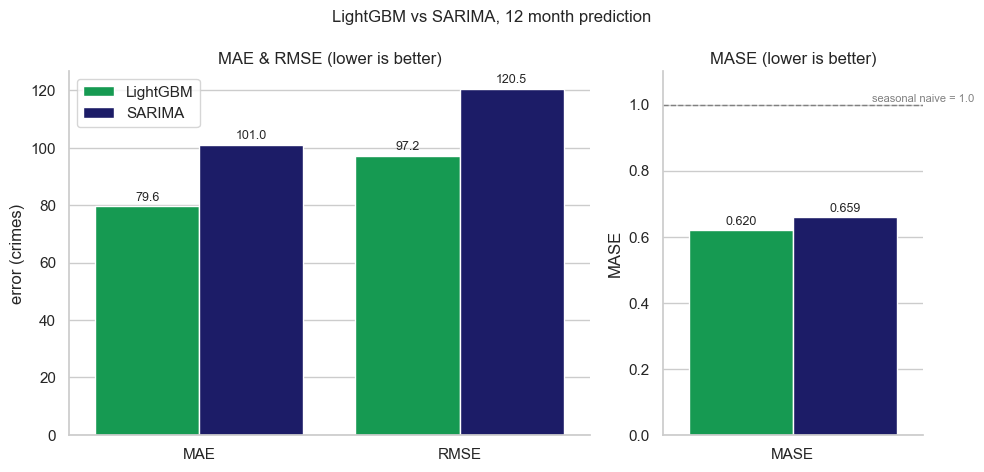

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# MAE/RMSE share a crimes-count scale; MASE is 0-1, so it needs its own panel

metrics_abs = pd.DataFrame({
    "metric": ["MAE", "MAE", "RMSE", "RMSE"],
    "value":  [79.58, 101.0, 97.18, 120.5],
    "model":  ["LightGBM", "SARIMA", "LightGBM", "SARIMA"],
})
metrics_mase = pd.DataFrame({
    "metric": ["MASE", "MASE"],
    "value":  [0.620, 0.659],
    "model":  ["LightGBM", "SARIMA"],
})
order = ["LightGBM", "SARIMA"]
palette = {"LightGBM": "#00b050", "SARIMA": "#101073"}
sns.set_theme(style="whitegrid")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.8),
                               gridspec_kw={"width_ratios": [2, 1]})

sns.barplot(data=metrics_abs, x="metric", y="value", hue="model",
            hue_order=order, palette=palette, ax=axL)
axL.set_xlabel(""); axL.set_ylabel("error (crimes)")
axL.set_title("MAE & RMSE (lower is better)")
axL.legend(title="")
for c in axL.containers:
    axL.bar_label(c, fmt="%.1f", fontsize=9, padding=2)

sns.barplot(data=metrics_mase, x="metric", y="value", hue="model",
            hue_order=order, palette=palette, ax=axR, legend=False)
axR.set_xlabel(""); axR.set_ylabel("MASE")
axR.set_title("MASE (lower is better)")
axR.axhline(1.0, ls="--", lw=1, color="gray")
axR.text(0.5, 1.01, "seasonal naive = 1.0", ha="center", fontsize=8, color="gray")
axR.set_ylim(0, 1.1)
for c in axR.containers:
    axR.bar_label(c, fmt="%.3f", fontsize=9, padding=2)

fig.suptitle("LightGBM vs SARIMA, 12 month prediction",
             fontsize=12)
sns.despine(); fig.tight_layout()
plt.show() 

In [ ]:
# 12-month recursive forecast — Base + COVID model (no external data)

FORECAST_MONTHS = pd.date_range('2026-03-01', periods=12, freq='MS')

# Build the Base + COVID feature frame (self-contained) 
COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-01')

feat_c = feat.copy()
feat_c['covid'] = ((feat_c['month'] >= COVID_START) &
                   (feat_c['month'] <= COVID_END)).astype(int)
FEATURES_C = FEATURES + ['covid']

#1. Train final Base + COVID model on full feat_c 
val_months_c = np.sort(feat_c['month'].unique())[-TEST_MONTHS:]
val_mask_c   = feat_c['month'].isin(val_months_c)

train_set_c = lgb.Dataset(
    feat_c.loc[~val_mask_c, FEATURES_C], feat_c.loc[~val_mask_c, TARGET],
    categorical_feature=CATEGORICAL)
val_set_c = lgb.Dataset(
    feat_c.loc[val_mask_c,  FEATURES_C], feat_c.loc[val_mask_c,  TARGET],
    reference=train_set_c, categorical_feature=CATEGORICAL)

model_c = lgb.train(
    params, train_set_c, num_boost_round=2000,
    valid_sets=[val_set_c],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
print(f'Base+COVID model — best iteration: {model_c.best_iteration}')

# 2. Recursive 12-month forecast (full panel, all forces)
running_c = dense.copy()


origin = running_c['month'].max()
last_obs = running_c.groupby(['force', 'crime_type'])['month'].transform('max')
running_c = running_c[last_obs >= origin - pd.DateOffset(months=2)].copy()

forecast_rows = []

for future_month in FORECAST_MONTHS:
    series_keys = running_c[['force', 'crime_type']].drop_duplicates()
    skeleton    = series_keys.assign(month=future_month, n_crimes=np.nan)

    extended = (
        pd.concat([running_c, skeleton], ignore_index=True)
        .sort_values(['force', 'crime_type', 'month'])
        .reset_index(drop=True)
    )

    feat_step   = add_features(extended)
    future_rows = feat_step[feat_step['month'] == future_month].copy()

    # COVID = 0 for all forecast months (restrictions ended mid-2021)
    future_rows['covid'] = 0

    future_rows['force']      = future_rows['force'].astype('category')
    future_rows['crime_type'] = future_rows['crime_type'].astype('category')

    preds = np.clip(
        model_c.predict(future_rows[FEATURES_C], num_iteration=model_c.best_iteration),
        0, None
    )

    pred_frame = future_rows[['force', 'crime_type', 'month']].copy()
    pred_frame['force']      = pred_frame['force'].astype(str)
    pred_frame['crime_type'] = pred_frame['crime_type'].astype(str)
    pred_frame['n_crimes']   = np.round(preds).astype(int)
    running_c = pd.concat([running_c, pred_frame], ignore_index=True)

    out_frame = pred_frame.rename(columns={'n_crimes': 'predicted_n_crimes'})
    forecast_rows.append(out_frame)
    print(f'  {future_month.strftime("%Y-%m")}: {len(out_frame)} series predicted')

forecast_df = pd.concat(forecast_rows, ignore_index=True)
forecast_df['month'] = pd.to_datetime(forecast_df['month']).dt.strftime('%Y-%m')
forecast_df = forecast_df.sort_values(['month', 'force', 'crime_type']).reset_index(drop=True)

out_path = r'C:\Users\20244270\OneDrive - TU Eindhoven\Desktop\CBL-COMMIT|cbl-realcrime\model'
forecast_df.to_csv(out_path, index=False)
print(f'\nSaved {len(forecast_df):,} rows -> {out_path}')
forecast_df.head(20)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 79.7623
[200]	valid_0's l1: 58.9229
[300]	valid_0's l1: 57.0857
[400]	valid_0's l1: 56.5272
[500]	valid_0's l1: 56.1912
[600]	valid_0's l1: 56.0888
Early stopping, best iteration is:
[575]	valid_0's l1: 55.9925
Base+COVID model — best iteration: 575
  2026-03: 588 series predicted
  2026-04: 588 series predicted
  2026-05: 588 series predicted
  2026-06: 588 series predicted
  2026-07: 588 series predicted
  2026-08: 588 series predicted
  2026-09: 588 series predicted
  2026-10: 588 series predicted
  2026-11: 588 series predicted
  2026-12: 588 series predicted
  2027-01: 588 series predicted
  2027-02: 588 series predicted

Saved 7,056 rows -> C:\Users\20244270\OneDrive - TU Eindhoven\Desktop\CBL-midterm\forecast_2026_03_to_2027_02.csv


,force,crime_type,month,predicted_n_crimes
0,Avon and Somerset Constabulary,Anti-social behaviour,2026-03,2285
1,Avon and Somerset Constabulary,Bicycle theft,2026-03,127
2,Avon and Somerset Constabulary,Burglary,2026-03,677
3,Avon and Somerset Constabulary,Criminal damage and arson,2026-03,1027
4,Avon and Somerset Constabulary,Drugs,2026-03,305
5,Avon and Somerset Constabulary,Other crime,2026-03,367
6,Avon and Somerset Constabulary,Other theft,2026-03,1060
7,Avon and Somerset Constabulary,Possession of weapons,2026-03,120
8,Avon and Somerset Constabulary,Public order,2026-03,1646
9,Avon and Somerset Constabulary,Robbery,2026-03,262


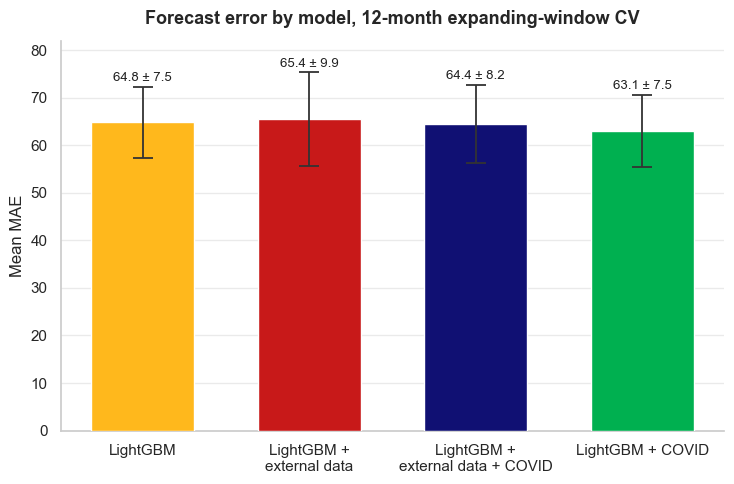

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Mean MAE and +- 1 SD across the 4 folds of the 12-month expanding-window CV.
results = {
    "LightGBM":               {"mae": 64.84, "std": 7.48, "color": "#ffb81c"},
    "LightGBM +\nexternal data":         {"mae": 65.44, "std": 9.88, "color": "#c81919"},
    "LightGBM +\nexternal data + COVID": {"mae": 64.42, "std": 8.19, "color": "#101073"},
    "LightGBM + COVID":       {"mae": 63.07, "std": 7.55, "color": "#00b050"},
}

labels = list(results)
means  = [results[k]["mae"]   for k in labels]
stds   = [results[k]["std"]   for k in labels]
colors = [results[k]["color"] for k in labels]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(labels, means, yerr=stds, capsize=7, color=colors, width=0.62, zorder=3,
       error_kw={"elinewidth": 1.3, "ecolor": "#333", "capthick": 1.3})

# Mean +- error printed above each whisker.
for x, (m, s) in enumerate(zip(means, stds)):
    ax.text(x, m + s + 0.6, f"{m:.1f} ± {s:.1f}",
            ha="center", va="bottom", fontsize=9.5, color="#222")

ax.set_ylim(0, 82)                        
ax.set_ylabel("Mean MAE")
ax.set_title("Forecast error by model, 12-month expanding-window CV", fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

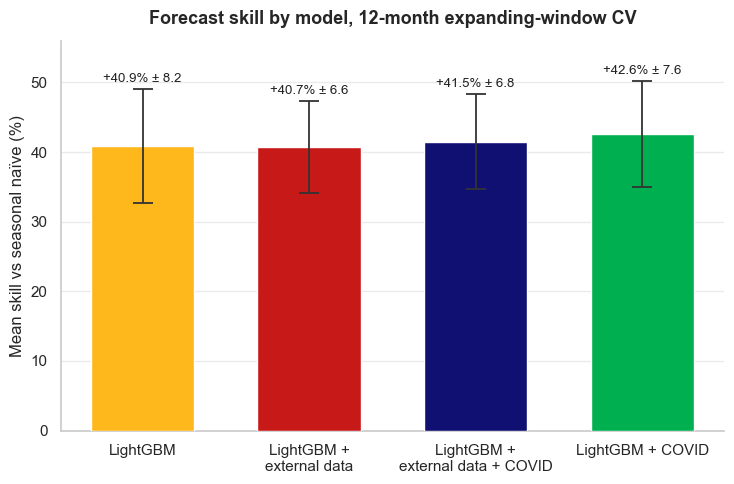

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Mean skill vs seasonal naive and +- SD across the 4 folds of the
# 12-month expanding-window CV. 
results = {
    "LightGBM":                          {"skill": 40.9, "std": 8.2, "color": "#ffb81c"},
    "LightGBM +\nexternal data":         {"skill": 40.7, "std": 6.6, "color": "#c81919"},
    "LightGBM +\nexternal data + COVID": {"skill": 41.5, "std": 6.8, "color": "#101073"},
    "LightGBM + COVID":                  {"skill": 42.6, "std": 7.6, "color": "#00b050"},
}

labels = list(results)
means  = [results[k]["skill"] for k in labels]
stds   = [results[k]["std"]   for k in labels]
colors = [results[k]["color"] for k in labels]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(labels, means, yerr=stds, capsize=7, color=colors, width=0.62, zorder=3,
       error_kw={"elinewidth": 1.3, "ecolor": "#333", "capthick": 1.3})

# Mean +- error printed above each whisker.
for x, (m, s) in enumerate(zip(means, stds)):
    ax.text(x, m + s + 0.6, f"+{m:.1f}% ± {s:.1f}",
            ha="center", va="bottom", fontsize=9.5, color="#222")

ax.set_ylim(0, 56)                         # full axis from 0
ax.set_ylabel("Mean skill vs seasonal naïve (%)")
ax.set_title("Forecast skill by model, 12-month expanding-window CV",
             fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()